https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch

from msi import LikelihoodFlow
from msi.utils import input_output
from msfm.utils import prior, parameters, files, logger

24-01-22 07:53:26   imports.py INF   Setting up healpy to run on 32 CPUs 


# load network predictions

### v4

In [3]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

In [4]:
# lensing
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# delta loss
model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# likelihood loss
# model_dir = "mse/2024-01-05_22-04-15_resnet_vanilla"
# model_dir = "mse/2024-01-08_06-13-14_resnet_vanilla"

n_steps = 100000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

### general

In [5]:
file_dict = input_output.load_preds(base_dir, model_dir, n_steps)

fidu_preds = file_dict["fiducial/vali/pred"]
grid_preds = file_dict["grid/pred"]
grid_cosmos = file_dict["grid/cosmo"]

# only relevant for the likelihood loss
n_params = len(params)
fidu_preds = fidu_preds[...,:n_params]
grid_preds = grid_preds[...,:n_params]

# combine the example and cosmology axes
grid_preds = np.concatenate(grid_preds, axis=0)
grid_cosmos = np.repeat(grid_cosmos, grid_preds.shape[0]//grid_cosmos.shape[0], axis=0)

print(f"\nShapes after concatenation:")
print(f"grid_preds  = {grid_preds.shape}")
print(f"grid_cosmos = {grid_cosmos.shape}")

24-01-22 07:53:36 input_output INF   Array shapes:
 
24-01-22 07:53:36 input_output INF   fiducial/vali/pred = (4, 5) 
24-01-22 07:53:36 input_output INF   grid/pred          = (2500, 48, 5) 
24-01-22 07:53:36 input_output INF   grid/cosmo         = (2500, 5) 
24-01-22 07:53:36 input_output INF   grid/i_sobol       = (2500,) 
24-01-22 07:53:36 input_output INF   grid/i_example     = (2500, 48) 
24-01-22 07:53:36 input_output INF   grid/i_noise       = (2500, 48) 

Shapes after concatenation:
grid_preds  = (120000, 5)
grid_cosmos = (120000, 5)


In [6]:
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_conductor"

n_examples = grid_preds.shape[0]
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

### observation

In [7]:
# i_obs = 0

i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
print(f"The example index closest to the median is {i_obs}")

obs_pred = fidu_preds[i_obs]


The example index closest to the median is 1


# likelihood Flow $p(x|\theta)$

In [8]:
flow = LikelihoodFlow(params, conf, out_dir=out_dir, label=label)

24-01-22 07:53:37 likelihood_f WAR   Assuming that the feature/summary dimension is equal to the context/parameter dimension 
24-01-22 07:53:37 likelihood_f INF   Using the default context embedding network: 
24-01-22 07:53:37 likelihood_f INF   <class 'enflows.nn.nets.resnet.ResidualNet'> 
24-01-22 07:53:37 likelihood_f INF   Using the default base distribution: 
24-01-22 07:53:37 likelihood_f INF   <class 'enflows.distributions.normal.StandardNormal'> 
24-01-22 07:53:37 likelihood_f INF   Using the default transform: 
24-01-22 07:53:37 likelihood_f INF   <class 'enflows.transforms.base.CompositeTransform'> 
24-01-22 07:53:37 likelihood_f INF   Initialized the normalizing flow 
24-01-22 07:53:37 likelihood_f INF   Running on device cuda with default float torch.float32 


### training

 15%|████                        |   | 44/300 [03:51<22:21,  5.24s/it]        lr: 9.48E-04, train: -6.30, vali: -7.78: 24-01-22 07:57:37   pytorch.py INF   <All keys matched successfully> 
24-01-22 07:57:37   pytorch.py INF   Restored the weights from the best epoch (vali_loss = -7.98) 
24-01-22 07:57:37 likelihood_f INF   Stopping early after 44 epochs 
 15%|████                        |   | 44/300 [03:56<22:56,  5.38s/it]        lr: 9.48E-04, train: -6.30, vali: -7.78: 


RuntimeError: Serialization of parametrized modules is only supported through state_dict(). See:
https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-a-general-checkpoint-for-inference-and-or-resuming-training

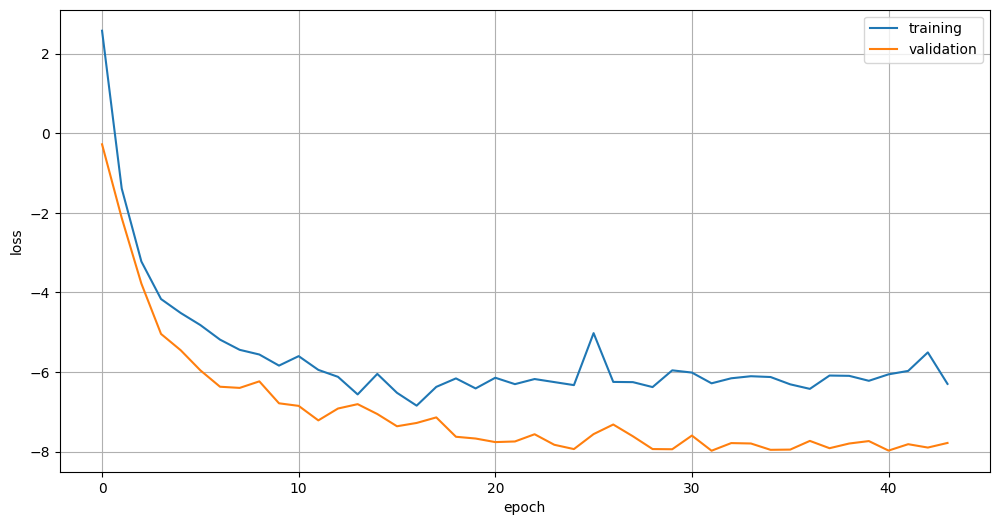

In [9]:
flow.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=300,
    # dataset
    batch_size=1024,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=100.0,
    learning_rate_min=1e-6,
    # early stopping
    n_patience_epochs=10,
    min_delta=0.0,
    save_model=True,
)

### MCMC

In [10]:
posterior_samples = flow.sample_posterior(
    obs_pred,
)

24-01-22 07:58:12      mcmc.py INF   Initial values in prior: True 
24-01-22 07:58:12      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-01-22 07:58:20      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:39<00:00, 12.54it/s]

24-01-22 07:59:00      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/chain_100000_conductor.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-01-22 07:59:07  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/contours_100000_conductor.png 


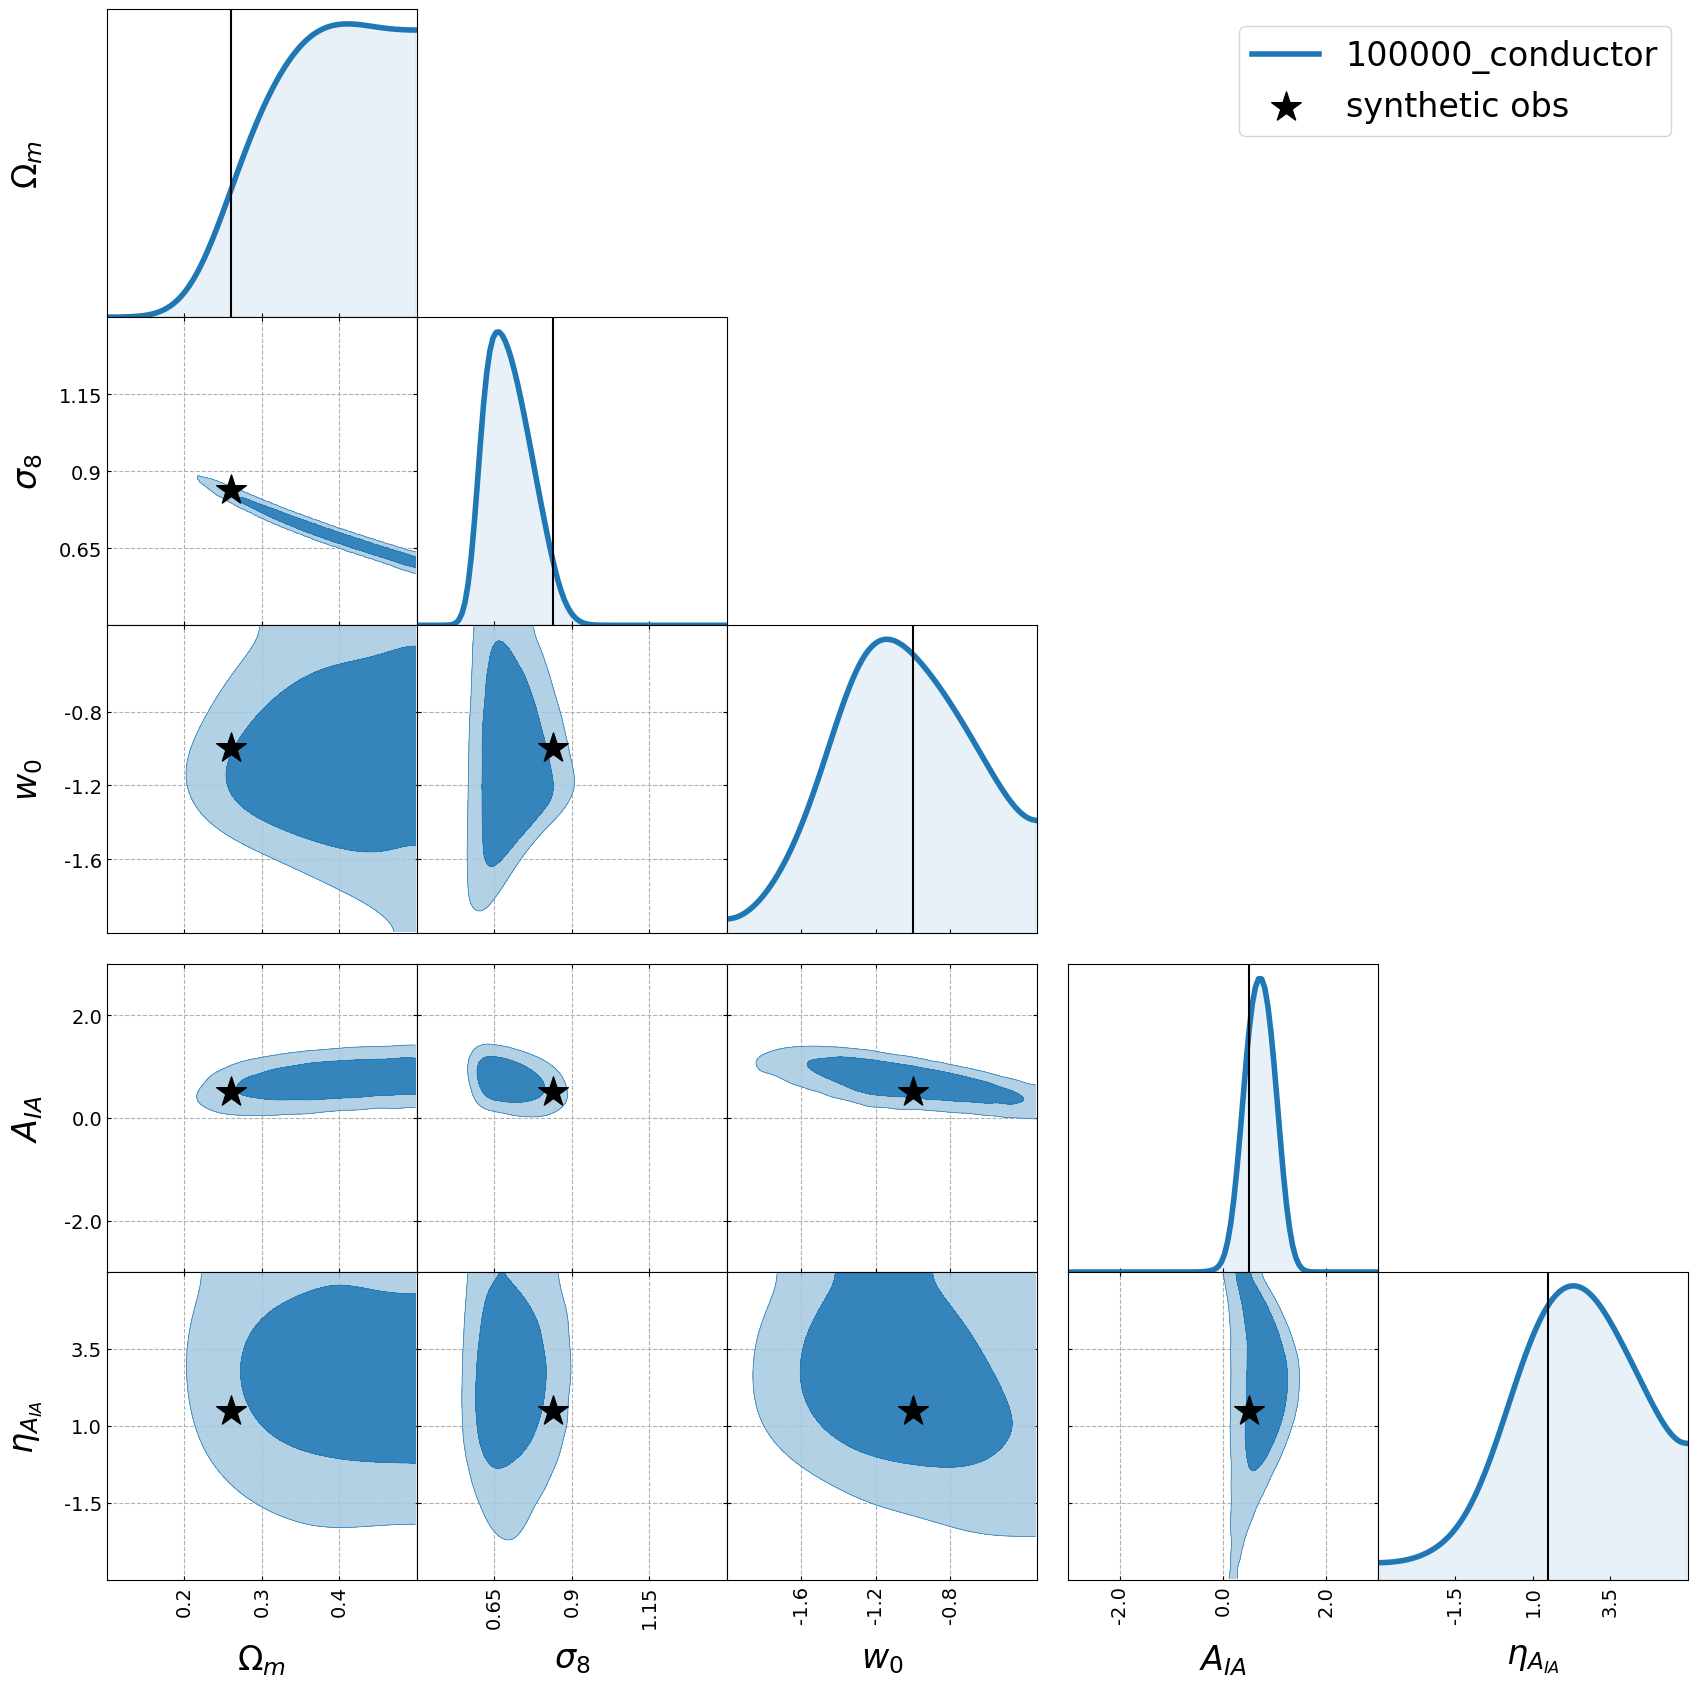

In [11]:
flow.plot_contours(
    posterior_samples,
)